In [ ]:
import ollama

messages = [
    {
        "role": "system",
        "content": "You are a helpful assistant."
    }
]


while True:
    user_input = input("You: ")

    if user_input.lower() == "exit":
        break

    messages.append(
    {
        "role": "user",
        "content": user_input
    }
    )

    response = ollama.chat(
    model="qwen3.5:2b",
    messages=messages,
    tools=tools
    )

    if response.message.tool_calls:
        tool_call = response.message.tool_calls[0]
        function_name = tool_call.function.name
        arguments = tool_call.function.arguments
        result = tool_map[function_name](**arguments)

        messages.append(
            {
                "role": "tool",
                "content": result
            }
        )

        final_response = ollama.chat(
            model="qwen3.5:2b",
            messages=messages,
            tools=tools
        )

        print(final_response.message.content)
    else: 
        reply = response["message"]["content"]
        print(reply)

In [ ]:
import os

def read_text_file(filename):

    if not filename:
        return "Error: No filename provided."

    if not os.path.exists(filename):
        return "Error: File does not exist."

    if not filename.endswith(".txt") and not filename.endswith(".csv"):
        return "Error: Unsupported file type."

    with open(filename, "r") as file:
        content = file.read()

    return content

In [15]:
tools = [
    {
        "type": "function",
        "function": {
            "name": "read_text_file",
            "description": "Reads and returns the contents of a text file.",
            "parameters": {
                "type": "object",
                "properties": {
                    "filename": {
                        "type": "string",
                        "description": "The name of the file to read."
                    }
                },
                "required": [
                    "filename"
                ]
            }
        }
    },

    {
    "type": "function",
    "function": {
        "name": "create_scatter_plot",
        "description": "Creates and displays a scatter plot from two columns of a CSV file.",
        "parameters": {
            "type": "object",
            "properties": {
                "filename": {
                    "type": "string",
                    "description": "The CSV file name."
                },
                "col1": {
                    "type": "string",
                    "description": "The column to use for the x-axis."
                },
                "col2": {
                    "type": "string",
                    "description": "The column to use for the y-axis."
                }
            },
            "required": [
                "filename",
                "col1",
                "col2"
            ]
        }
    }
}
]

In [13]:
tool_map = {
    "read_text_file": read_text_file,
    "create_scatter_plot": create_scatter_plot
}

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [7]:
def create_scatter_plot(filename, col1, col2):

    if not filename:
        return "Error: No filename provided."

    if not col1:
        return "Error: No first column provided."

    if not col2:
        return "Error: No second column provided."

    if not os.path.exists(filename):
        return "Error: File does not exist."

    df = pd.read_csv(filename)

    if col1 not in df.columns:
        return f"Error: Column {col1} does not exist."

    if col2 not in df.columns:
        return f"Error: Column {col2} does not exist."

    plt.figure(figsize=(7,5))

    plt.scatter(
            df[col1],
            df[col2]
        )

    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs {col2}")

    plt.show()
    return "Scatter plot created successfully."

In [ ]:
create_scatter_plot(
    "student-scores.csv",
    "weekly_self_study_hours",
    "math_score"
)

In [21]:
messages = [
    {
        "role": "system",
        "content": "You are a helpful assistant with access to tools."
    },
    {
        "role": "user",
        "content": 
        "Create a scatter plot from student-scores.csv using weekly_self_study_hours and math_score."
    }
]

In [22]:
import ollama
response = ollama.chat(
    model="qwen3.5:2b",
    messages=messages,
    tools=tools
)

In [23]:
response.message.tool_calls

[ToolCall(function=Function(name='create_scatter_plot', arguments={'filename': 'student-scores.csv', 'col1': 'weekly_self_study_hours', 'col2': 'math_score'}))]

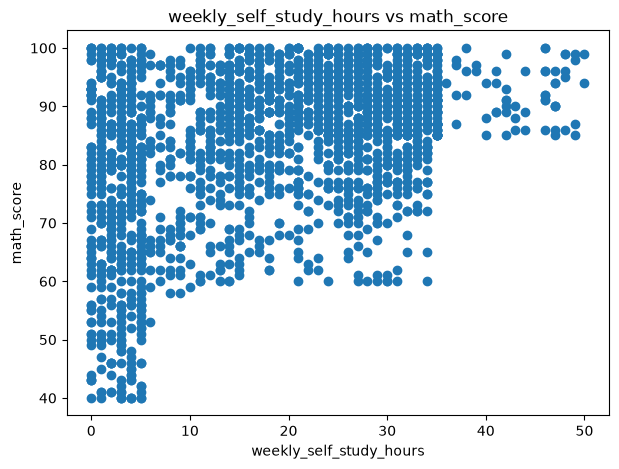

Scatter plot created successfully.


In [24]:
tool_call = response.message.tool_calls[0]

function_name = tool_call.function.name

arguments = tool_call.function.arguments

result = tool_map[function_name](**arguments)

print(result)

In [ ]:
import ollama
import pandas as pd
import matplotlib.pyplot as plt
import os


def create_scatter_plot(filename, col1, col2):

    if not filename:
        return "Error: No filename provided."

    if not col1:
        return "Error: No first column provided."

    if not col2:
        return "Error: No second column provided."

    if not os.path.exists(filename):
        return "Error: File does not exist."

    df = pd.read_csv(filename)

    if col1 not in df.columns:
        return f"Error: Column {col1} does not exist."

    if col2 not in df.columns:
        return f"Error: Column {col2} does not exist."

    plt.figure(figsize=(7,5))

    plt.scatter(
            df[col1],
            df[col2]
        )

    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs {col2}")

    plt.show()
    return "Scatter plot created successfully."

def read_text_file(filename):

    if not filename:
        return "Error: No filename provided."

    if not os.path.exists(filename):
        return "Error: File does not exist."

    if not filename.endswith(".txt") and not filename.endswith(".csv"):
        return "Error: Unsupported file type."

    with open(filename, "r") as file:
        content = file.read()

    return content

tool_map = {
    "read_text_file": read_text_file,
    "create_scatter_plot": create_scatter_plot
}

tools = [
    {
        "type": "function",
        "function": {
            "name": "read_text_file",
            "description": "Reads and returns the contents of a text file.",
            "parameters": {
                "type": "object",
                "properties": {
                    "filename": {
                        "type": "string",
                        "description": "The name of the file to read."
                    }
                },
                "required": [
                    "filename"
                ]
            }
        }
    },

    {
    "type": "function",
    "function": {
        "name": "create_scatter_plot",
        "description": "Creates and displays a scatter plot from two columns of a CSV file.",
        "parameters": {
            "type": "object",
            "properties": {
                "filename": {
                    "type": "string",
                    "description": "The CSV file name."
                },
                "col1": {
                    "type": "string",
                    "description": "The column to use for the x-axis."
                },
                "col2": {
                    "type": "string",
                    "description": "The column to use for the y-axis."
                }
            },
            "required": [
                "filename",
                "col1",
                "col2"
            ]
        }
    }
}
]


messages = [
    {
        "role": "system",
        "content": "You are a helpful assistant."
    }
]

while True:
    user_input = input("You: ")

    if user_input.lower() == "exit":
        break

    messages.append(
    {
        "role": "user",
        "content": user_input
    }
    )

    response = ollama.chat(
    model="qwen3.5:2b",
    messages=messages,
    tools=tools
    )

    if response.message.tool_calls:
        tool_call = response.message.tool_calls[0]
        function_name = tool_call.function.name
        arguments = tool_call.function.arguments
        result = tool_map[function_name](**arguments)

        messages.append(
            {
                "role": "tool",
                "content": result
            }
        )

        final_response = ollama.chat(
            model="qwen3.5:2b",
            messages=messages,
            tools=tools
        )

        print(final_response.message.content)
    else: 
        reply = response["message"]["content"]
        print(reply)